In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Shape After Removing Duplicates: (200, 5)


In [7]:
df = df.drop(
    columns=["CustomerID"]
)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [8]:
df["Gender"] = df["Gender"].map(
    {
        "Male":1,
        "Female":0
    }
)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [9]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 200
Columns: 4


In [11]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

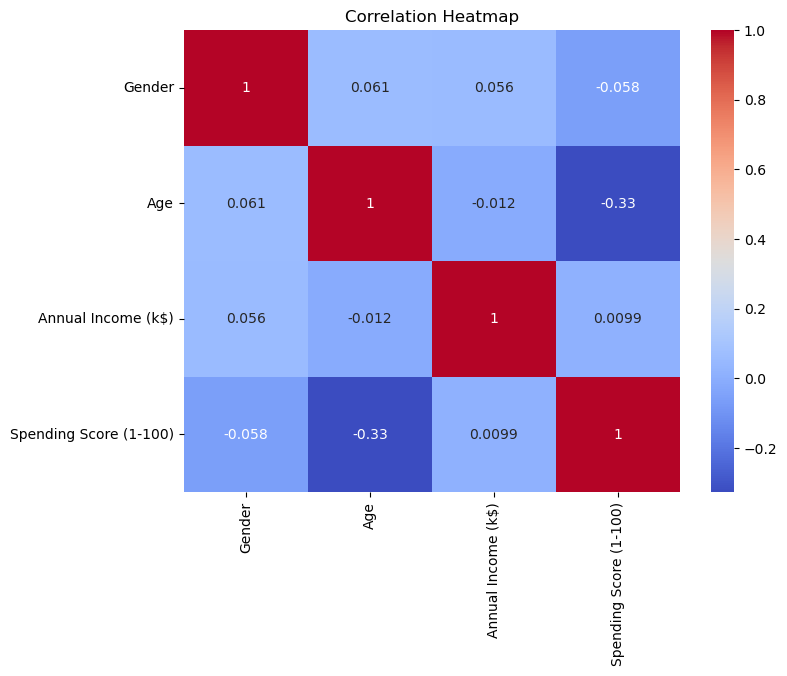

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

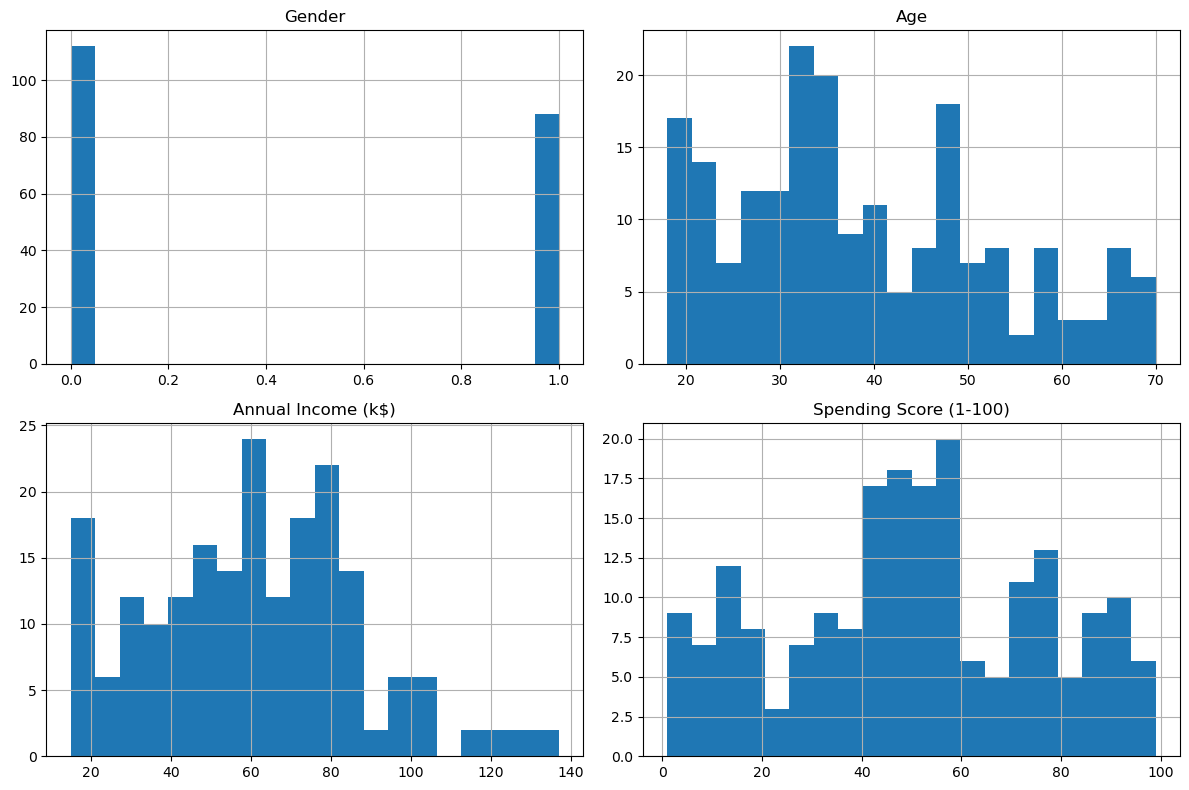

In [13]:
df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

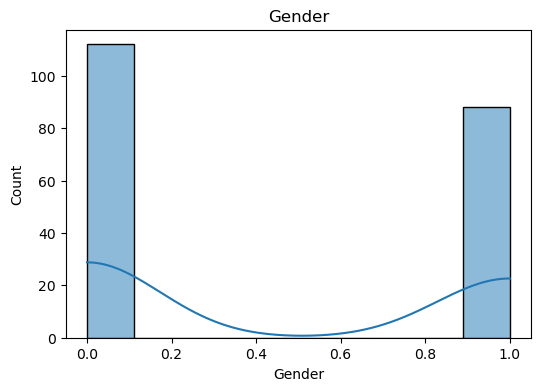

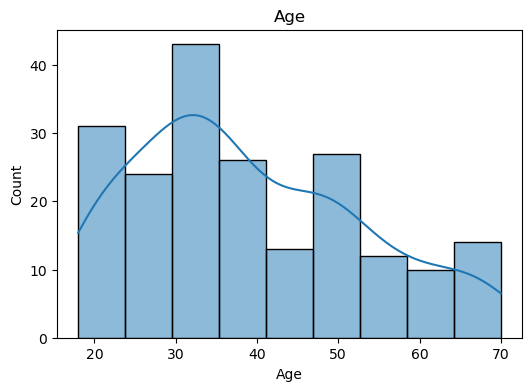

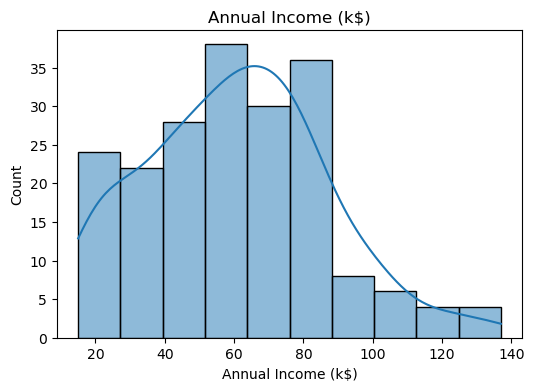

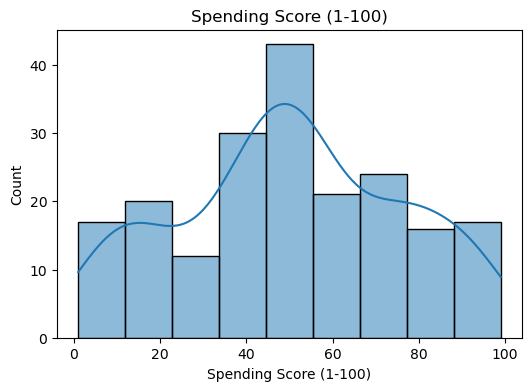

In [14]:
for col in df.columns:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

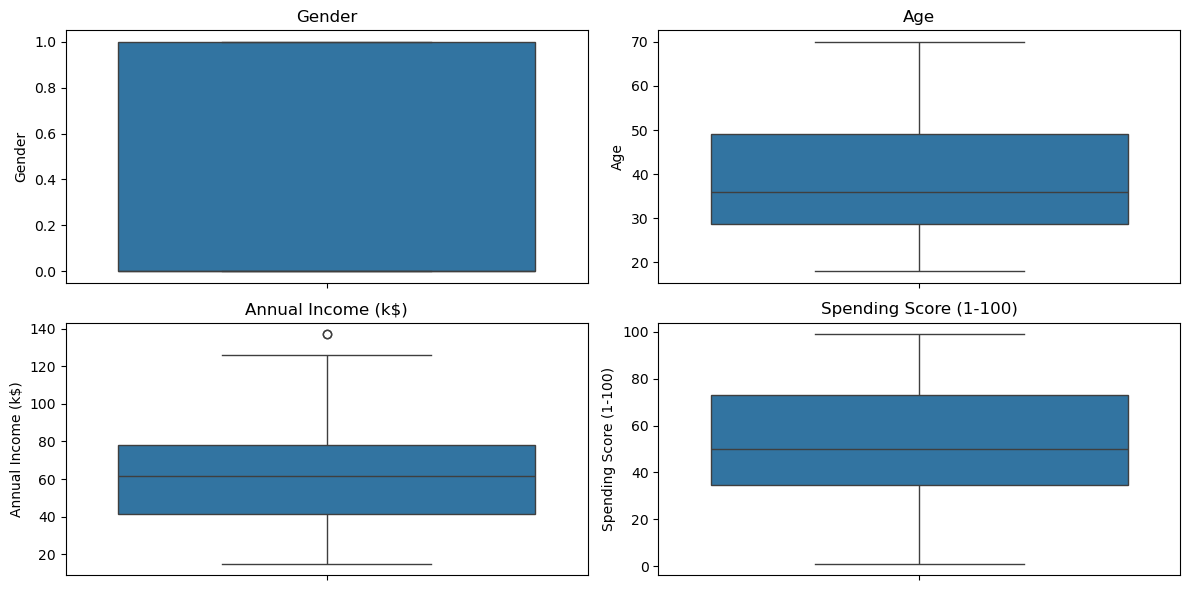

In [15]:
plt.figure(figsize=(12,6))

for i,col in enumerate(df.columns):

    plt.subplot(
        2,
        2,
        i+1
    )

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()

plt.show()

In [16]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

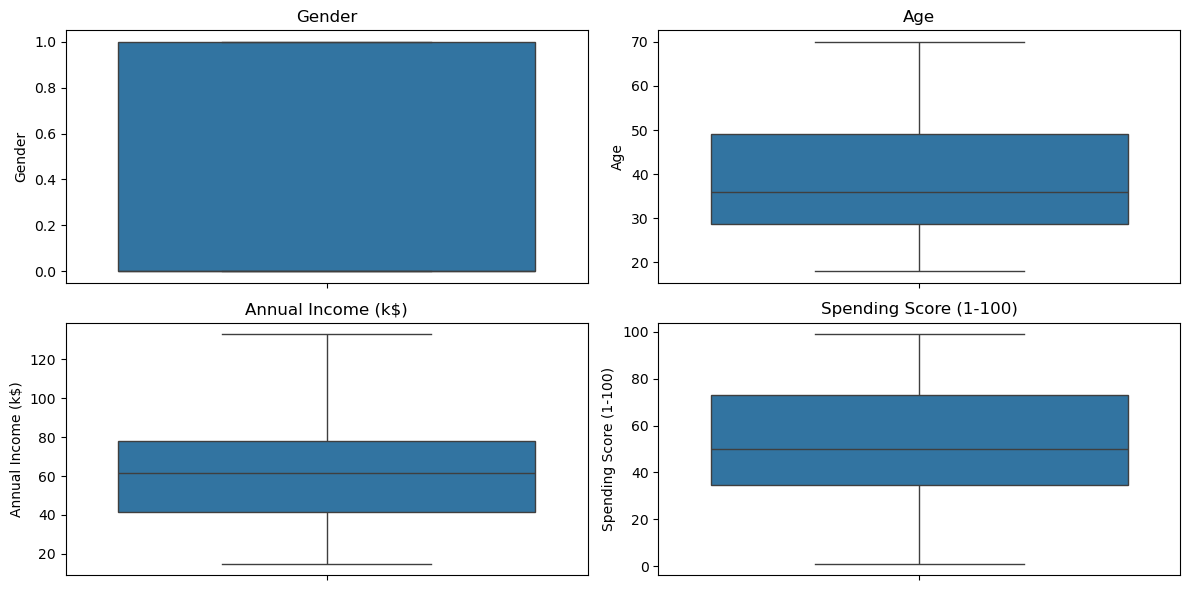

In [17]:
plt.figure(figsize=(12,6))

for i,col in enumerate(df.columns):

    plt.subplot(
        2,
        2,
        i+1
    )

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()

plt.show()

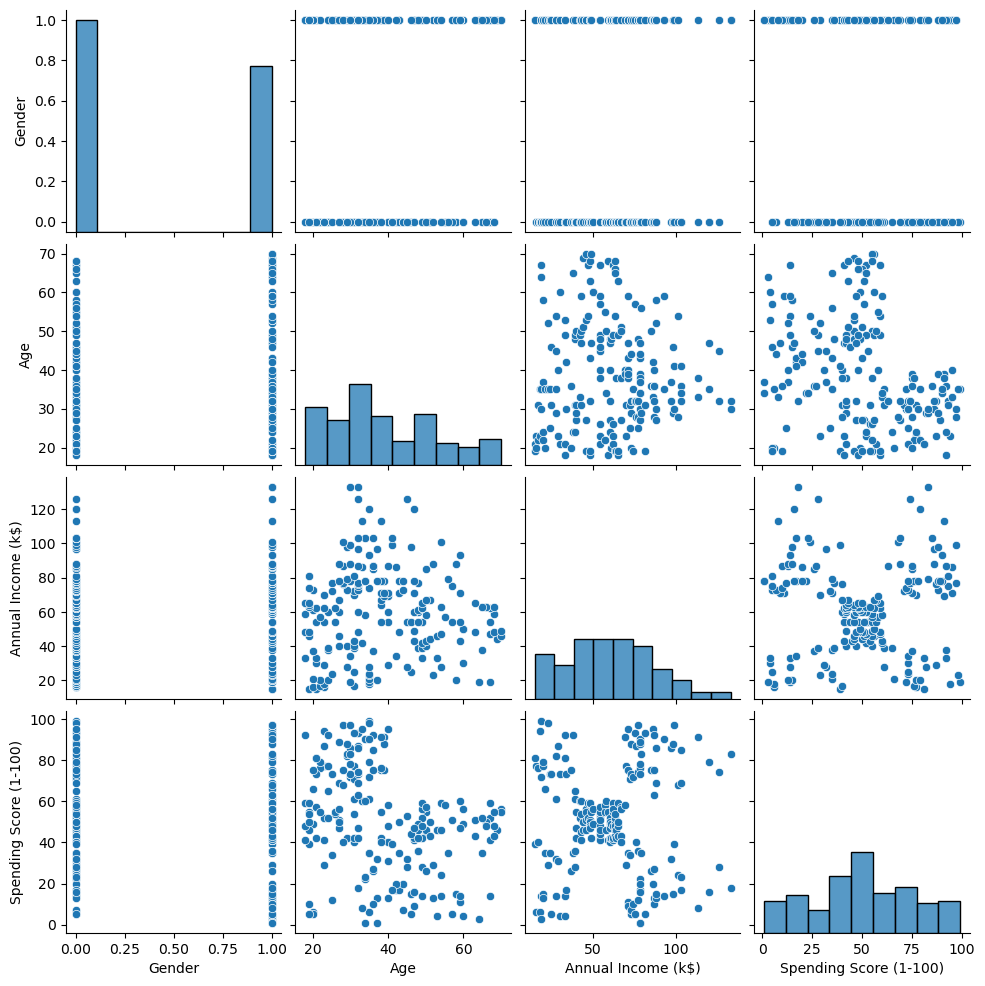

In [18]:
sns.pairplot(
    df
)

plt.show()

In [19]:
X = df.copy()

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,19.0,15.0,39.0
1,1.0,21.0,15.0,81.0
2,0.0,20.0,16.0,6.0
3,0.0,23.0,16.0,77.0
4,0.0,31.0,17.0,40.0


In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.12815215, -1.42456879, -1.74542941, -0.43480148],
       [ 1.12815215, -1.28103541, -1.74542941,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70708307, -1.71591298],
       [-0.88640526, -1.13750203, -1.70708307,  1.04041783],
       [-0.88640526, -0.56336851, -1.66873673, -0.39597992]])

In [21]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.745429,-0.434801
1,1.128152,-1.281035,-1.745429,1.195704
2,-0.886405,-1.352802,-1.707083,-1.715913
3,-0.886405,-1.137502,-1.707083,1.040418
4,-0.886405,-0.563369,-1.668737,-0.395980


In [22]:
scaled_df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,3.108624e-17,-1.021405e-16,1.421085e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-8.864053e-01,-1.496335e+00,-1.745429e+00,-1.910021e+00
25%,-8.864053e-01,-7.248436e-01,-7.292515e-01,-5.997931e-01
50%,-8.864053e-01,-2.045351e-01,3.767528e-02,-7.764312e-03
75%,1.128152e+00,7.284319e-01,6.703898e-01,8.851316e-01
max,1.128152e+00,2.235532e+00,2.769852e+00,1.894492e+00


In [23]:
scaled_df.to_csv(
    "../data/mall_cleaned.csv",
    index=False
)

print(
    "mall_cleaned.csv saved successfully"
)

mall_cleaned.csv saved successfully


In [24]:
final_df = pd.read_csv(
    "../data/mall_cleaned.csv"
)

final_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.745429,-0.434801
1,1.128152,-1.281035,-1.745429,1.195704
2,-0.886405,-1.352802,-1.707083,-1.715913
3,-0.886405,-1.137502,-1.707083,1.040418
4,-0.886405,-0.563369,-1.668737,-0.395980


In [25]:
print(
    "Final Shape:",
    final_df.shape
)

Final Shape: (200, 4)
